In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('FinalData.csv')
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
fdf=df[df['COD to site recode']==df['Cancer_type']]
df.head(5)

,Sex,Year of diagnosis,"Race and origin recode (NHW, NHB, NHAIAN, NHAPI, Hispanic)",Marital status at diagnosis,Primary Site,Histologic Type ICD-O-3,Survival months,Vital status recode (study cutoff used),COD to site recode,Rural-Urban Continuum Code,Age,Cancer_type,Stage,Treatment,Income
0,Female,2003,Non-Hispanic White,Divorced,Axillary tail of breast,Ductal/Lobular,14.0,1,Breast,Counties in metropolitan areas ge 1 million pop,77.0,Breast,Unknown,Surgery,114999.5
1,Female,2010,Non-Hispanic Black,Single (never married),"Breast, NOS (Not Otherwise Specified)",Ductal/Lobular,12.0,1,Diseases of Heart,Counties in metropolitan areas ge 1 million pop,72.0,Breast,I,Surgery+Radiation,97499.5
2,Female,2018,Non-Hispanic White,Single (never married),Overlapping lesion of breast,Ductal/Lobular,70.0,0,Alive,Counties in metropolitan areas ge 1 million pop,72.0,Breast,I,Surgery+Radiation+Chemotherapy,120000.0
3,Female,2023,Hispanic (All Races),Married (including common law),Upper-outer quadrant of breast,Ductal/Lobular,11.0,0,Alive,Counties in metropolitan areas ge 1 million pop,62.0,Breast,I,Radiation,120000.0
4,Female,2005,Non-Hispanic White,Widowed,Central portion of breast,Ductal/Lobular,81.0,1,Breast,Counties in metropolitan areas ge 1 million pop,62.0,Breast,II,Unknown,104999.5


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4198697 entries, 0 to 4198696
Data columns (total 15 columns):
 #   Column                                                      Dtype  
---  ------                                                      -----  
 0   Sex                                                         object 
 1   Year of diagnosis                                           int64  
 2   Race and origin recode (NHW, NHB, NHAIAN, NHAPI, Hispanic)  object 
 3   Marital status at diagnosis                                 object 
 4   Primary Site                                                object 
 5   Histologic Type ICD-O-3                                     object 
 6   Survival months                                             float64
 7   Vital status recode (study cutoff used)                     int64  
 8   COD to site recode                                          object 
 9   Rural-Urban Continuum Code                                  object 
 10  Age   

In [4]:
Cancer_freq=pd.DataFrame({
    'Frequency':df['Cancer_type'].value_counts(),
    'Percentage':df['Cancer_type'].value_counts(normalize = True)*100
})
Cancer_freq

,Frequency,Percentage
Cancer_type,,
Breast,1435703,34.194013
Prostate,1324278,31.540214
Lung and Bronchus,1133140,26.987896
Stomach,154503,3.679784
Liver,151073,3.598092


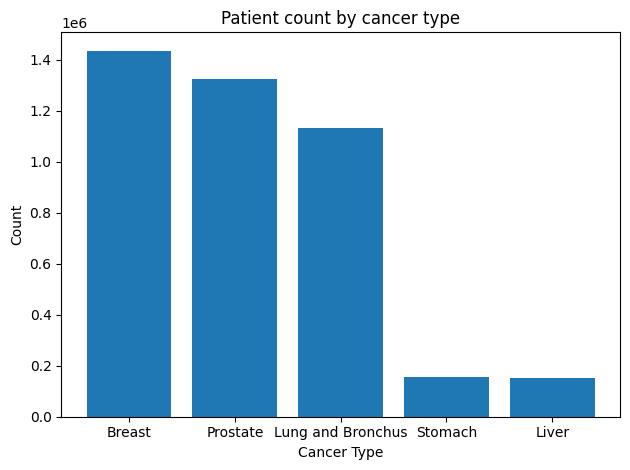

In [5]:
cancer_counts = df['Cancer_type'].value_counts()
plt.bar(cancer_counts.index, cancer_counts.values,)
plt.title('Patient count by cancer type')
plt.ylabel('Count')
plt.xlabel('Cancer Type')
plt.tight_layout()
plt.savefig('fig1.png')
plt.show()

In [6]:
Cancer_Age=df[['Age','Cancer_type']].groupby('Cancer_type').describe()
skewness = df.groupby('Cancer_type')['Age'].skew().rename('skewness')
kurtosis = df.groupby('Cancer_type')['Age'].apply(pd.Series.kurtosis).rename('kurtosis')
Cancer_Age = pd.concat([Cancer_Age, skewness, kurtosis], axis=1)
Cancer_Age

,"(Age, count)","(Age, mean)","(Age, std)","(Age, min)","(Age, 25%)","(Age, 50%)","(Age, 75%)","(Age, max)",skewness,kurtosis
Cancer_type,,,,,,,,,,
Breast,1435703.0,61.956608,13.819473,0.0,52.0,62.0,72.0,90.0,-0.064466,-0.609676
Liver,151073.0,64.871698,12.942554,0.0,57.0,67.0,72.0,90.0,-1.010282,3.725012
Lung and Bronchus,1133140.0,69.781335,10.995857,0.0,62.0,72.0,77.0,90.0,-0.453186,0.248250
Prostate,1324278.0,67.289379,9.379024,0.0,62.0,67.0,72.0,90.0,0.049710,-0.180654
Stomach,154503.0,67.454373,13.984756,0.0,57.0,67.0,77.0,90.0,-0.536674,-0.066188


<Figure size 800x600 with 0 Axes>

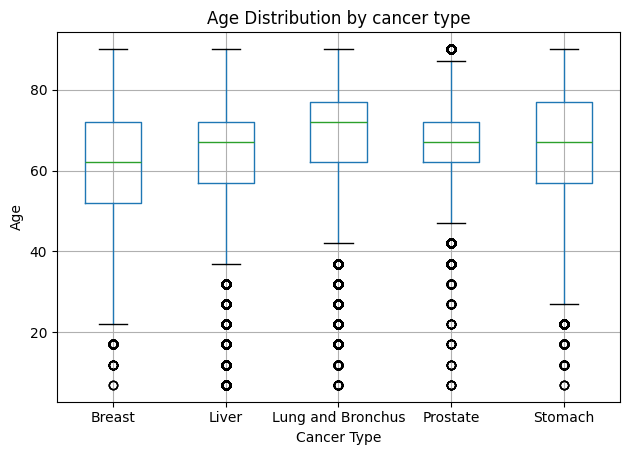

In [7]:
plt.figure(figsize=(8,6))
df[df['Age'] > 5].boxplot(column='Age',by='Cancer_type')
plt.title('Age Distribution by cancer type')
plt.suptitle('')
plt.ylabel('Age')
plt.xlabel('Cancer Type')
plt.tight_layout()
plt.savefig('fig2.png')
plt.show()

In [8]:
Sex_ctype=pd.DataFrame({
    'Frequency':df[['Sex','Cancer_type']].groupby('Cancer_type').value_counts(),
    'Percentage':df[['Sex','Cancer_type']].groupby('Cancer_type').value_counts(normalize=True)*100,
})
Sex_ctype

Frequency  Percentage
Cancer_type       Sex                          
Breast            Female    1424810   99.241278
                  Male        10893    0.758722
Liver             Male       111546   73.835828
                  Female      39527   26.164172
Lung and Bronchus Male       593634   52.388407
                  Female     539506   47.611593
Prostate          Male      1324278  100.000000
Stomach           Male        92626   59.950939
                  Female      61877   40.049061

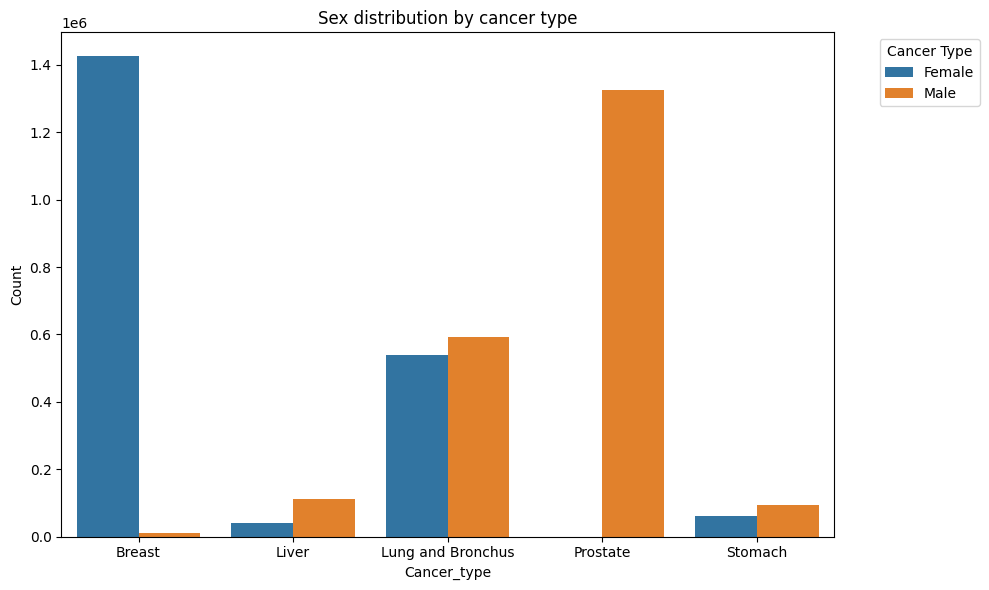

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(df,x='Cancer_type',hue='Sex',)
plt.title('Sex distribution by cancer type')
plt.ylabel('Count')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.savefig('fig3.png')
plt.show()

In [10]:
stage_ctype1=pd.crosstab(df['Cancer_type'], df['Stage'])
stage_ctype2 = pd.crosstab(df['Cancer_type'], df['Stage'],normalize='index') * 100
stage_ctype2.index.name = 'Cancer'
stage_ctype2 = stage_ctype2.round(2)
print(stage_ctype1,stage_ctype2)

Stage                   I      II     III      IV  Unknown
Cancer_type                                               
Breast             789384   24181  321213   71941   228971
Liver               65165   29838    4904   21163    30002
Lung and Bronchus  211123   64943  139721  490935   226417
Prostate           839628  115756   24089   76687   268114
Stomach             41107    6183   26028   44675    36510 Stage                  I     II    III     IV  Unknown
Cancer                                                
Breast             54.98   1.68  22.37   5.01    15.95
Liver              43.14  19.75   3.25  14.01    19.86
Lung and Bronchus  18.63   5.73  12.33  43.33    19.98
Prostate           63.40   8.74   1.82   5.79    20.25
Stomach            26.61   4.00  16.85  28.92    23.63


<Figure size 1500x450 with 0 Axes>

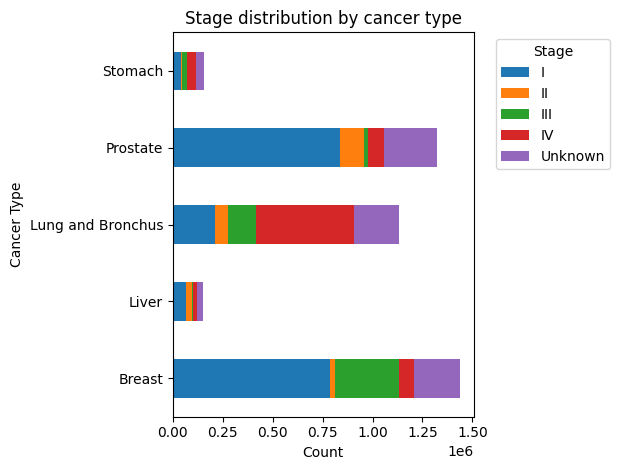

In [11]:
stagectype=pd.crosstab(df['Cancer_type'],df['Stage'])
plt.figure(figsize=(15,4.5))
stagectype.plot(kind='barh',stacked=True)
plt.title('Stage distribution by cancer type')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.legend(title='Stage', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.savefig('fig4.png')
plt.show()

In [12]:
hist2 = pd.DataFrame({
    'Frequency': df.groupby('Cancer_type')['Histologic Type ICD-O-3'].value_counts(),
    'Percentage': df.groupby('Cancer_type')['Histologic Type ICD-O-3'].value_counts(normalize=True) * 100
})
hist2 = hist2.loc[hist2.groupby(level='Cancer_type')['Percentage'].idxmax()]
hist2 = hist2.sort_values(by='Percentage', ascending=True)
hist2

,,Frequency,Percentage
Cancer_type,Histologic Type ICD-O-3,,
Lung and Bronchus,Large Cell,374363,33.037665
Stomach,Adenocarcinoma,105202,68.090587
Liver,Hepatocellular,135843,89.918781
Breast,Ductal/Lobular,1364630,95.049603
Prostate,Adenocarcinoma,1279938,96.651760


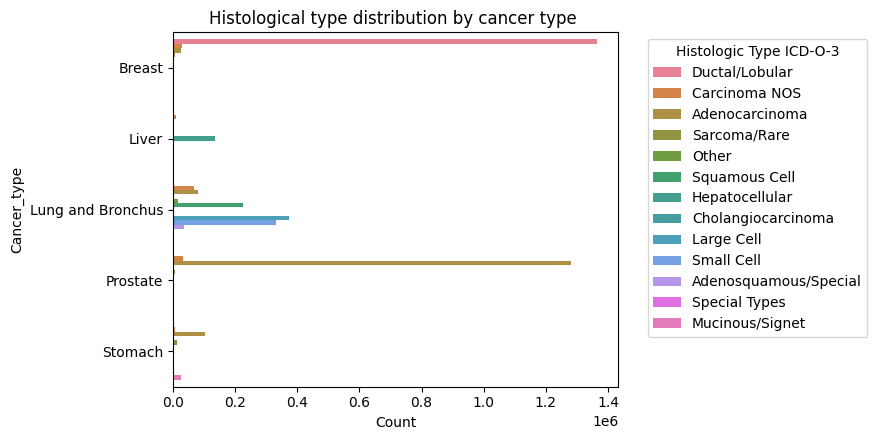

In [13]:
hist1 = df[['Histologic Type ICD-O-3', 'Cancer_type']].groupby('Cancer_type').value_counts().reset_index(name='Count')
plt.figure(figsize=(9,4.5))
sns.barplot(data=hist1, hue='Histologic Type ICD-O-3', x='Count', y='Cancer_type')
plt.title('Histological type distribution by cancer type ')
plt.xlabel('Count')
plt.legend(title='Histologic Type ICD-O-3', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig5.png')
plt.show()

In [14]:
sur_ctype=fdf[['Survival months','Cancer_type']].groupby('Cancer_type').describe()
skewness = fdf.groupby('Cancer_type')['Survival months'].skew().rename('skewness')
kurtosis = fdf.groupby('Cancer_type')['Survival months'].apply(pd.Series.kurtosis).rename('kurtosis')
sur_ctype = pd.concat([sur_ctype, skewness, kurtosis], axis=1)
sur_ctype

,"(Survival months, count)","(Survival months, mean)","(Survival months, std)","(Survival months, min)","(Survival months, 25%)","(Survival months, 50%)","(Survival months, 75%)","(Survival months, max)",skewness,kurtosis
Cancer_type,,,,,,,,,,
Breast,195109.0,52.506722,49.798479,0.0,16.0,37.0,74.0,287.0,1.468102,2.084414
Liver,77880.0,12.976168,20.383525,0.0,1.0,5.0,16.0,252.0,3.228576,15.154646
Lung and Bronchus,719108.0,14.455909,23.551927,0.0,2.0,6.0,17.0,284.0,3.711621,19.028721
Prostate,113918.0,61.099633,57.712381,0.0,16.0,41.0,92.0,287.0,1.181766,0.746494
Stomach,65326.0,12.437406,19.883262,0.0,2.0,6.0,15.0,280.0,4.363533,28.515175


<Figure size 1000x600 with 0 Axes>

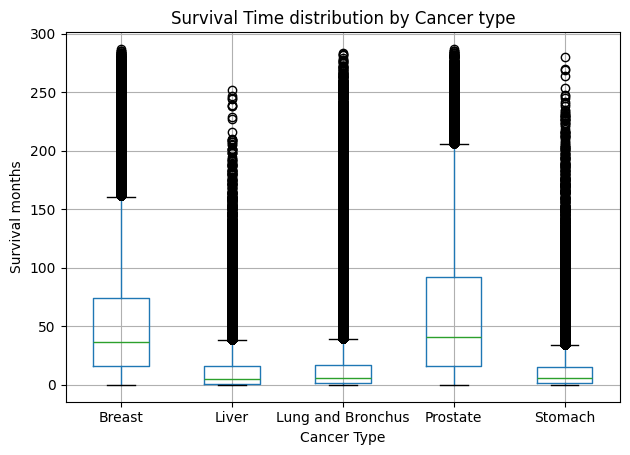

In [15]:
plt.figure(figsize=(10,6))
fdf.boxplot(column='Survival months',by='Cancer_type')
plt.title('Survival Time distribution by Cancer type')
plt.suptitle('')
plt.ylabel('Survival months')
plt.xlabel('Cancer Type')
plt.tight_layout()
plt.savefig('fig6.png')
plt.show()

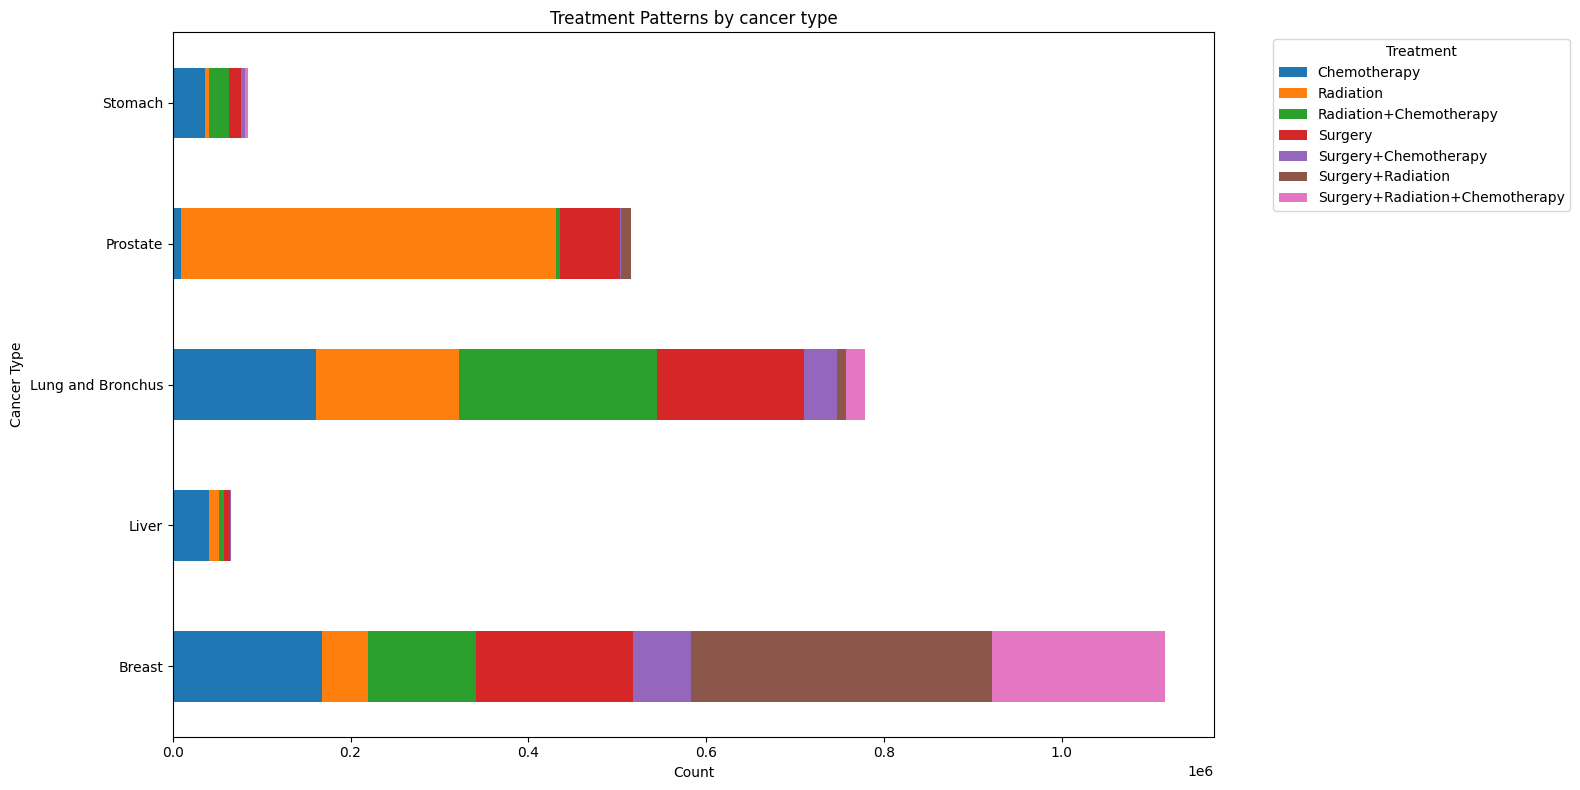

In [16]:
df_treat = df[df['Treatment'] != 'Unknown'] 
Treat_ctype = pd.crosstab(df_treat['Cancer_type'], df_treat['Treatment'])
Treat_ctype.plot(kind='barh', stacked=True, figsize=(16, 8))
plt.title('Treatment Patterns by cancer type')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.legend(title='Treatment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig7.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
geo_ctype = pd.crosstab(df['Cancer_type'], df['Rural-Urban Continuum Code'],normalize='index') * 100
geo_ctype.index.name = 'Cancer'
geo_ctype = geo_ctype.round(2)
geo_ctype

Rural-Urban Continuum Code,Counties in metropolitan areas ge 1 million pop,"Counties in metropolitan areas of 250,000 to 1 million pop",Counties in metropolitan areas of lt 250 thousand pop,Nonmetropolitan counties adjacent to a metropolitan area,Nonmetropolitan counties not adjacent to a metropolitan area,Unknown/missing/no match (Alaska or Hawaii - Entire State),Unknown/missing/no match/Not 1990-2024
Cancer,,,,,,,
Breast,61.37,20.47,7.43,6.39,4.20,0.11,0.02
Liver,62.32,20.49,7.02,5.97,4.03,0.15,0.02
Lung and Bronchus,54.28,20.48,9.14,9.40,6.54,0.14,0.01
Prostate,59.34,20.61,8.19,7.26,4.51,0.05,0.04
Stomach,63.30,19.48,6.86,6.01,4.08,0.27,0.01


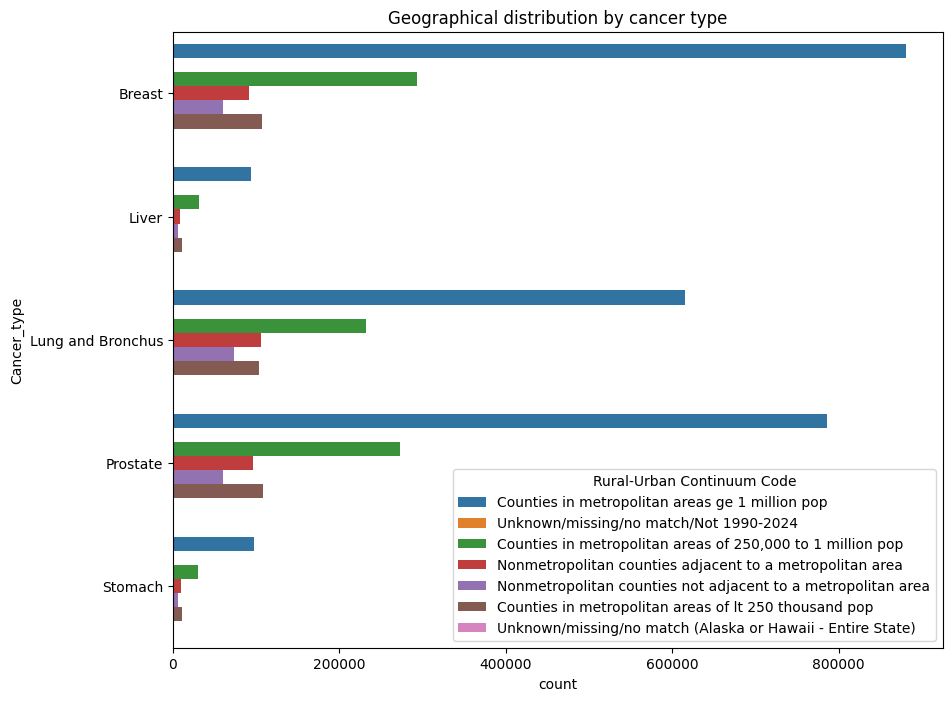

In [18]:
plt.figure(figsize=(14,8))
sns.countplot(df,y='Cancer_type',hue='Rural-Urban Continuum Code',)
plt.title('Geographical distribution by cancer type')
plt.legend(title='Rural-Urban Continuum Code', loc='lower right') 
plt.subplots_adjust(left=0.35)
plt.savefig('fig8.png', dpi=300, bbox_inches='tight')
plt.show()

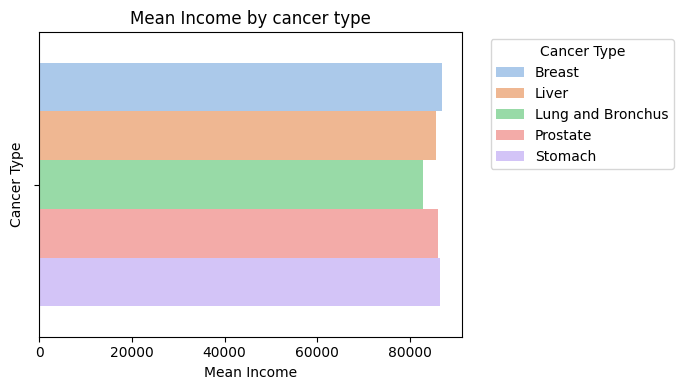

In [19]:
plt.figure(figsize=(7,4))
mean_income = df.groupby('Cancer_type')['Income'].mean().reset_index()
sns.barplot(data=mean_income, hue='Cancer_type', x='Income',palette='pastel')
plt.title('Mean Income by cancer type')
plt.xlabel('Mean Income')
plt.ylabel('Cancer Type')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.savefig('fig9.png')
plt.show()

<Figure size 1000x600 with 0 Axes>

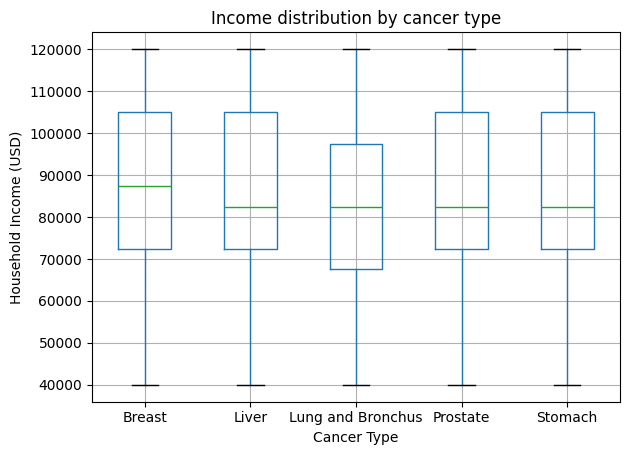

In [20]:
plt.figure(figsize=(10, 6))
df.boxplot(column='Income', by='Cancer_type')
plt.title('Income distribution by cancer type')
plt.suptitle('')
plt.xlabel('Cancer Type')
plt.ylabel('Household Income (USD)')
plt.tight_layout()
plt.savefig('fig9b_income_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

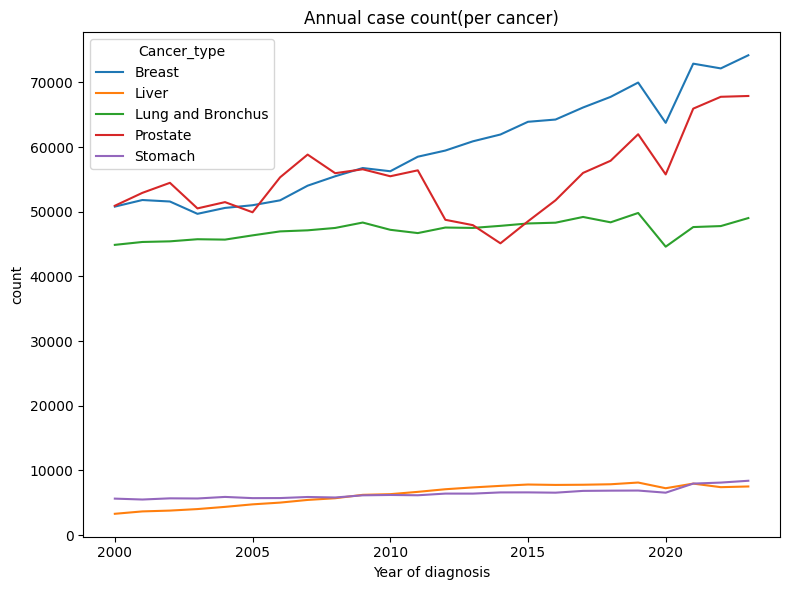

In [21]:
cpy=df[['Year of diagnosis','Cancer_type']].groupby('Cancer_type').value_counts()
cpy=pd.DataFrame(cpy)
cpy.sort_index()
plt.figure(figsize=(8,6))
sns.lineplot(cpy,x='Year of diagnosis',y='count',hue='Cancer_type',)
plt.title('Annual case count(per cancer)')
plt.tight_layout()
plt.savefig('fig10.png')
plt.show()

In [22]:
cpy1=pd.crosstab(df['Year of diagnosis'],df['Cancer_type'])
cpy1

Cancer_type,Breast,Liver,Lung and Bronchus,Prostate,Stomach
Year of diagnosis,,,,,
2000,50799,3303,44885,50930,5649
2001,51818,3672,45331,52926,5510
2002,51587,3799,45429,54477,5693
2003,49683,4033,45755,50522,5670
2004,50596,4373,45696,51493,5912
2005,51012,4763,46352,49923,5725
2006,51769,5034,46967,55326,5736
2007,54035,5447,47132,58842,5901
2008,55488,5709,47500,55966,5824


In [ ]:
Tables=[Cancer_freq,Cancer_Age,Sex_ctype,stage_ctype1,stage_ctype2,hist,sur_ctype,Treat_ctype,geo_ctype,mean_income,cpy1]
  

In [1]:
#saving all results in different sheets of an excel workbook 
sheet_names = [
    "Cancer_Frequency", 
    "Cancer_Age", 
    "Sex_per_Cancer", 
    "Stage_per_Cancer1",
    "Stage_per_Cancer2",
    "Histology", 
    "Survival", 
    "Treatment", 
    "Geography", 
    "Mean_Income",'cpy'
]
with pd.ExcelWriter("cancer_data_summary.xlsx", engine="openpyxl") as writer:
    for table, name in zip(Tables, sheet_names):
        table.to_excel(writer, sheet_name=name)
print("Successfully saved all tables to 'cancer_data_summary.xlsx'!")

NameError: name 'pd' is not defined